# Question 1

Amelia Jiang-Yu: ajiangy1@jhu.edu  
Raj Gosain: rgosain3@jhu.edu

# Question 2

Link: https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand

Our data details the number of public bicycles rented each hour via the Seoul Bike Sharing System. We also have information about the weather as well as whether it is a holiday. This data is from before the COVID-19 pandemic. 

# Question 3

The response variable is Rented Bike Count, the number of bikes rented at each hour. This is a nonnegative integer.

# Question 4

Temperature: continuous, in Celsius  
Visibility: integer-valued  
Hour: integer-valued  
Seasons: categorical (Winter, Spring, Summer, Autumn)  
Holiday: binary (Holiday or No Holiday) 

# Question 5

Since we are modeling the count of bikes rented at each hour, we believe the Poisson GLM is most appropriate. 

$$
Y_i \sim \text{Poisson}(\mu_i), \qquad i = 1,2,\dots,n
$$

where

$$
\mu_i = \mathbb{E}[Y_i \mid \mathbf{x}_i].
$$

The model is

$$
\log(\mu_i) = \eta_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_p x_{ip}.
$$

Equivalently,

$$
\mu_i = \exp\!\left(\beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_p x_{ip}\right).
$$


# Question 6

In [3]:
import pandas as pd
df = pd.read_csv("SeoulBikeData.csv", encoding="latin-1")

In [5]:
print(df.shape)
df.head()

(8760, 14)


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [15]:
continuous_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = ['Date', 'Seasons']
binary_cols = ['Holiday', 'Functioning Day']

print("Categorical:", categorical_cols)
print("Continuous:", continuous_cols)
print("Binary:", binary_cols)

Categorical: ['Date', 'Seasons']
Continuous: ['Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']
Binary: ['Holiday', 'Functioning Day']


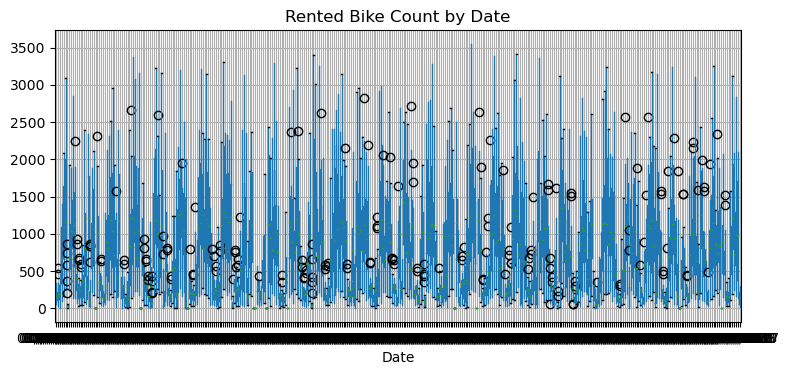

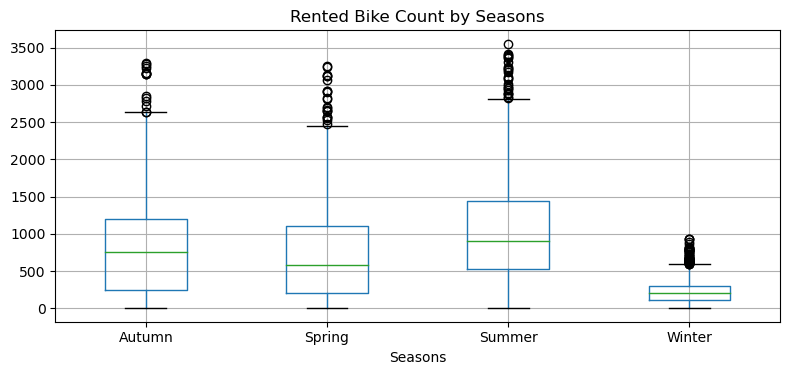

In [14]:
import matplotlib.pyplot as plt

Y = 'Rented Bike Count'

for col in categorical_cols:
    if col != Y:
        df.boxplot(column=Y, by=col, figsize=(8, 4))
        plt.title(f'{Y} by {col}')
        plt.suptitle('')
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

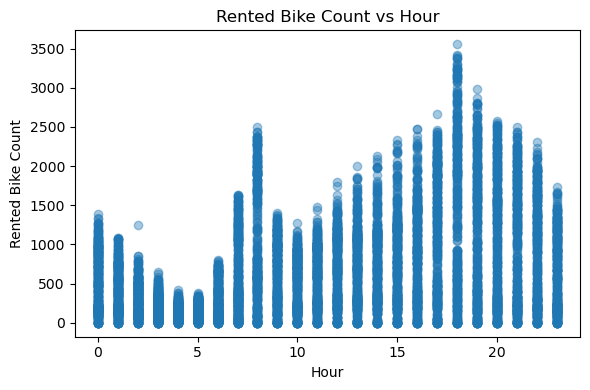

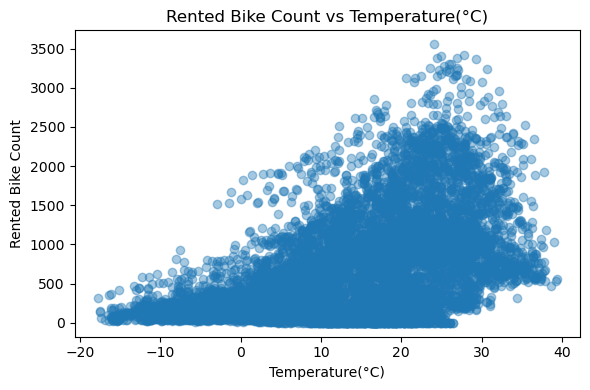

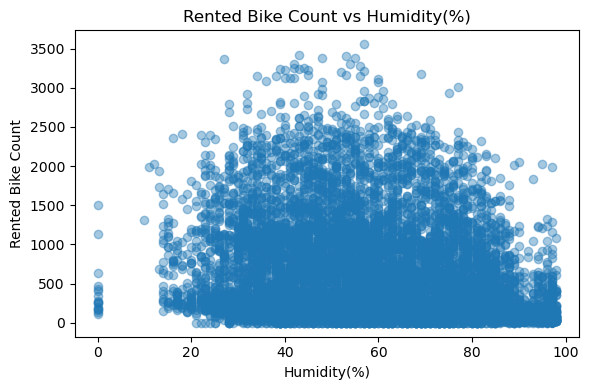

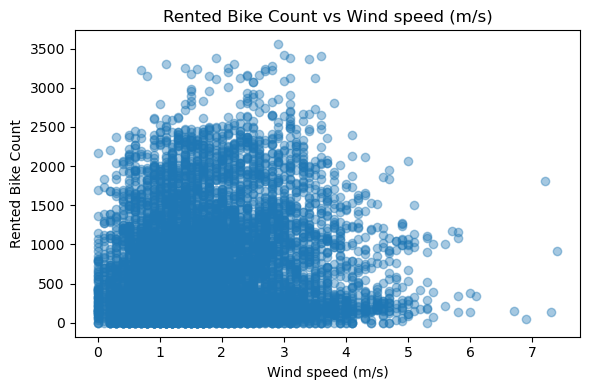

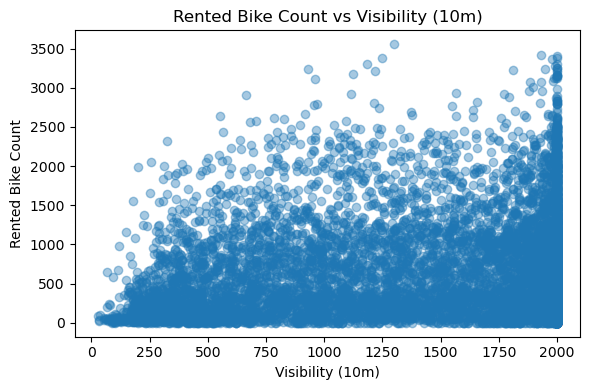

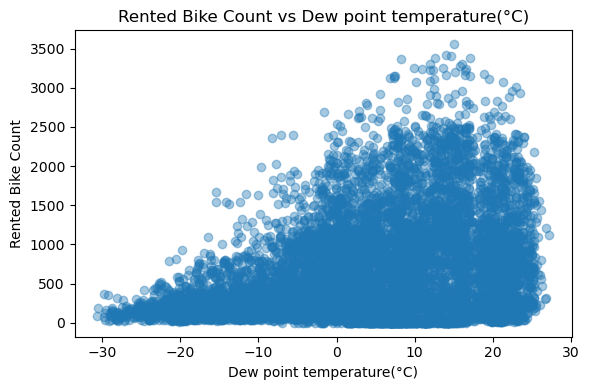

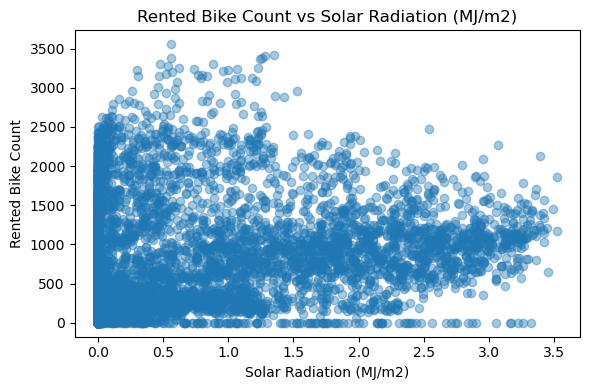

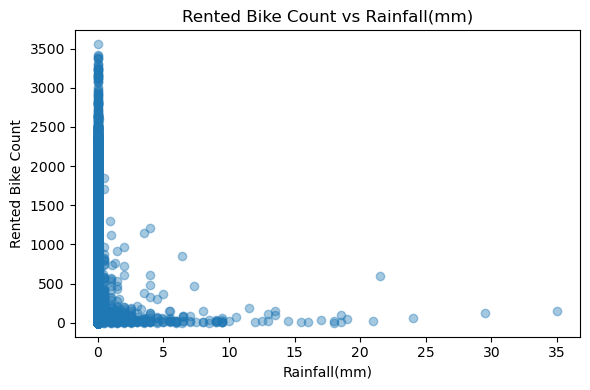

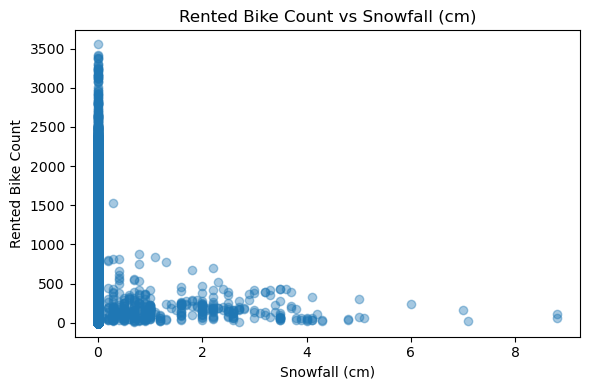

In [10]:
Y = 'Rented Bike Count'

for col in continuous_cols:
    if col != Y:
        plt.figure(figsize=(6, 4))
        plt.scatter(df[col], df[Y], alpha=0.4)
        plt.xlabel(col)
        plt.ylabel(Y)
        plt.title(f'{Y} vs {col}')
        plt.tight_layout()
        plt.show()

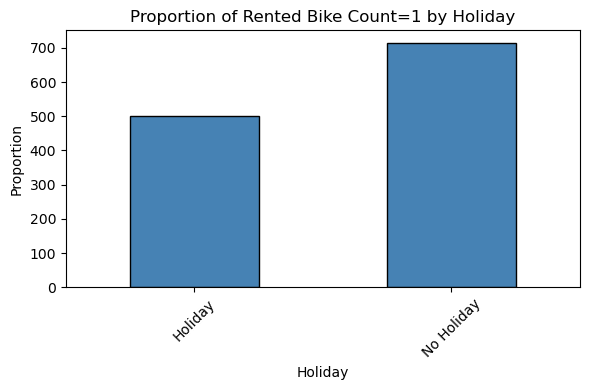

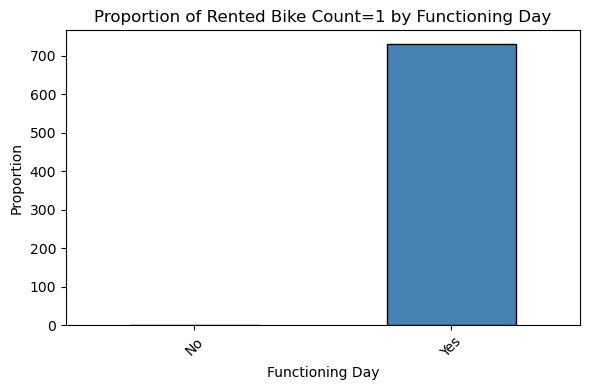

In [16]:
Y = 'Rented Bike Count'

for col in binary_cols:
    if col != Y:
        prop = df.groupby(col)[Y].mean()
        prop.plot(kind='bar', figsize=(6, 4), color='steelblue', edgecolor='black')
        plt.title(f'Proportion of {Y}=1 by {col}')
        plt.ylabel('Proportion')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

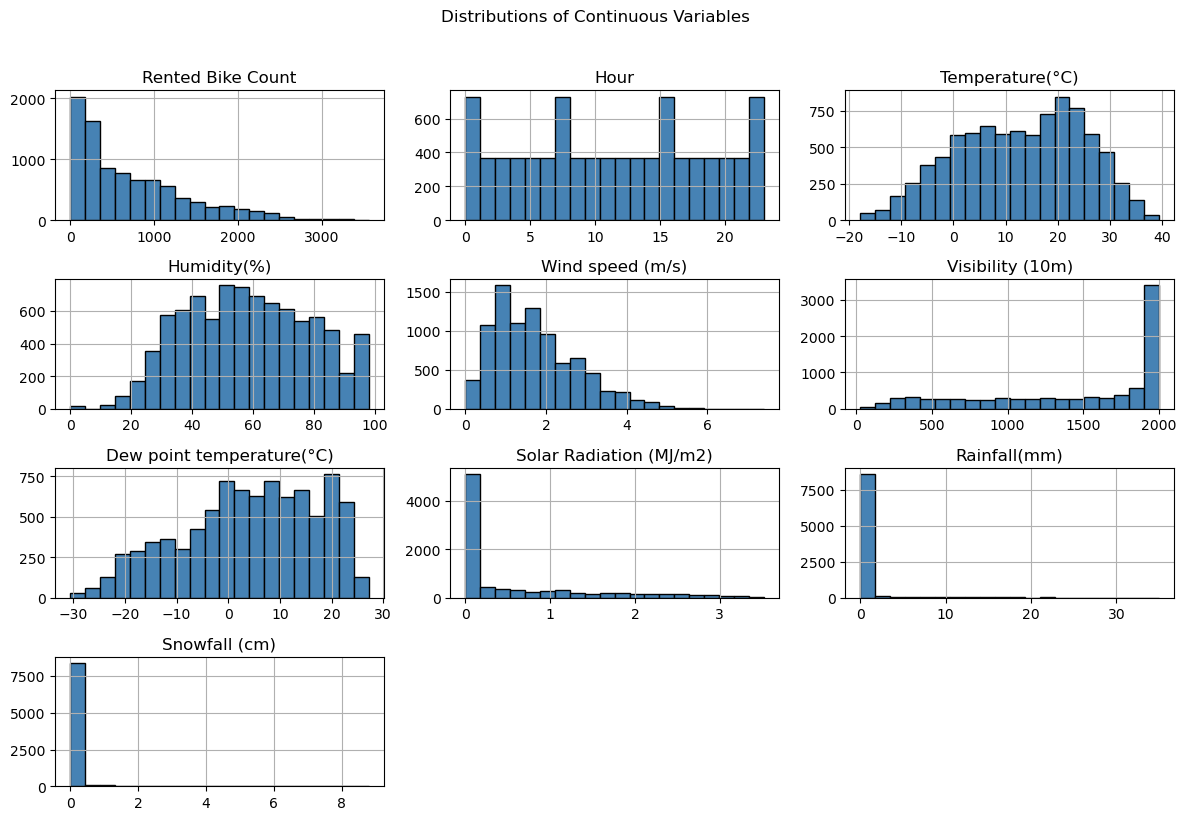

In [17]:
df[continuous_cols].hist(figsize=(12, 8), bins=20, edgecolor='black', color='steelblue')
plt.suptitle('Distributions of Continuous Variables', y=1.02)
plt.tight_layout()
plt.show()